### Immersive Travel Assistant — Powered by Gemma 3n

#### Challenge:
- Build a private, offline-first, multimodal AI that delivers real-world impact.

#### Problem Addressed:
- Lost in Translation: Empowering Travelers Without Internet
- Millions of travelers, backpackers, and aid workers venture into remote areas with limited connectivity — places where basic communication becomes a challenge. They face:
- Unfamiliar signs, menus, and symbols
- Local speech and dialects they don’t understand
- No mobile data or internet for translation apps
- Cultural mistakes due to lack of localized knowledge
- These moments create confusion, risk, and missed opportunities for human connection.

#### Solution: Gemma 3n-Powered Immersive Travel Translator

We built a fully offline, multimodal translator that runs directly on-device using Gemma 3n.

With a single photo, phrase, or audio snippet, the assistant:
- Understands signs and menus visually (via image input)
- Interprets local speech (via simulated or real transcripts)
- Translates content into English
- Provides cultural and etiquette tips
- Suggests polite replies or safety precautions

All responses are returned in a structured JSON format — clean, parseable, and ready for real-world UX.

#### Impact Potential
- Travelers in rural areas or countries without cellular data
- Elderly tourists using devices without privacy compromise
- Field aid workers or volunteers navigating unknown languages
- Language learners practicing polite, cultural interactions

#### What Makes It Unique?
- Not just translation — it understands context and etiquette
- Works with images, speech, or text
- Fully private and offline
- Easy to extend to other use cases (e.g., refugee navigation, education)

In [1]:
!pip install -q timm --upgrade
!pip install -q accelerate
!pip install -q git+https://github.com/huggingface/transformers.git

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import transformers
import torch
import gc
try:
    del model
    torch.cuda.empty_cache()
    gc.collect()
except:
    pass
torch.cuda.reset_peak_memory_stats()
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, AutoProcessor, AutoModelForImageTextToText
from PIL import Image
import torch
import json
import re
import os
os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["DISABLE_TORCH_COMPILE"] = "1"
import kagglehub
import requests
from io import BytesIO
from IPython.display import display, HTML
import base64

GEMMA_PATH = kagglehub.model_download("google/gemma-3n/transformers/gemma-3n-e2b-it")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Gett

2025-07-14 18:05:41.788486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752516341.994594      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752516342.051053      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [2]:
def get_best_gpu():
    if not torch.cuda.is_available():
        return torch.device("cpu")

    best_gpu = None
    max_free_mem = 0

    for i in range(torch.cuda.device_count()):
        stats = torch.cuda.memory_stats(i)
        free_mem = torch.cuda.get_device_properties(i).total_memory - stats["allocated_bytes.all.current"]
        print(f"GPU {i} free memory: {free_mem / (1024**3):.2f} GB")

        if free_mem > max_free_mem:
            max_free_mem = free_mem
            best_gpu = i

    print(f"Best GPU selected: {best_gpu} (Free: {max_free_mem / (1024**3):.2f} GB)")
    return torch.device(f"cuda:{best_gpu}")

# device = get_best_gpu()
device = "cpu" # GPU had some compilation issues, hence CPU for avoiding errors.

model = AutoModelForImageTextToText.from_pretrained(GEMMA_PATH, 
                                                    device_map=None, 
                                                    torch_dtype="auto").to(device)

processor = AutoProcessor.from_pretrained(GEMMA_PATH)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [3]:
print(type(model))

<class 'transformers.models.gemma3n.modeling_gemma3n.Gemma3nForConditionalGeneration'>


In [4]:
# Testing model load
prompt = """It was a dark and stormy night. """
input_ids = processor(text=prompt, return_tensors="pt").to(model.device, dtype=torch.float16)
outputs = model.generate(**input_ids, max_new_tokens=256, disable_compile=True)
text = processor.batch_decode(
    outputs,
    skip_special_tokens=False,
    clean_up_tokenization_spaces=False 
)
print(text[0])

<bos>It was a dark and stormy night. 

The rain lashed against the windows, and the wind howled like a banshee. Lightning illuminated the room in stark, fleeting flashes, revealing shadows that danced and writhed like demons. 

A figure huddled in the corner, cloaked in darkness, their face hidden from view. They trembled, not from the cold, but from a fear that gnawed at their soul.

Suddenly, a low, rhythmic tapping began. It started softly, almost imperceptibly, then grew in intensity, like a heartbeat echoing in the silence.

The tapping continued, relentless and unwavering. It seemed to emanate from somewhere within the walls, a strange and unsettling presence.

The figure in the corner began to stir. Their hand reached out, hesitant, and touched the wall.  

The tapping intensified. 

With a sudden, sharp movement, the figure recoiled, a gasp escaping their lips.

The tapping stopped.

Silence.

Then, a single word, whispered on the wind: "Remember..."



**What is the significan

In [5]:
def create_unified_prompt(input_content: str, location_hint: str = "Unknown"):
    return f""" 
                You are a multilingual travel assistant running completely offline. Based on the input provided (image, audio, or text), perform the following steps carefully and return a structured JSON.
                
                ---

                TASKS:
                1. Automatically determine the input type: image, speech, or text.
                2. If the input is an **image**:
                   - Extract any visible text (OCR) and translate it into English.
                   - Describe what the image contains (e.g., a road sign, a menu).
                3. If the input is **spoken** or **written**:
                   - Transcribe it (if needed), translate to English, and interpret its meaning.
                4. In all cases:
                   - Identify what kind of object it is (e.g., signboard, menu, spoken phrase).
                   - Suggest a polite or practical reply if appropriate.
                   - Offer at least one cultural or etiquette tip related to the input or region.
                
                Context:
                Region hint: {location_hint}
                
                ---

                Please respond **strictly enclosed in triple backticks and labeled `json`**, like this:

                
                ---
                
                ```json
                {{
                  "input_type": "<image / speech / text>",
                  "description": "<brief description of the content>",
                  "extracted_text": [
                    {{ "original": "<text>", "translation": "<translation>" }}
                  ],
                  "object_type": "<menu, sign, phrase, etc.>",
                  "suggested_reply": "<if relevant>",
                  "cultural_tips": ["<tip1>", "<tip2>"]
                }}
                ```
                Now analyze this input:
                {input_content}
            """

def detect_input_type(input_data):
    if isinstance(input_data, str) and input_data.endswith((".png", ".jpg", ".jpeg")):
        return "image"
    elif isinstance(input_data, str) and input_data.endswith((".wav", ".mp3")):
        return "audio"
    else:
        return "text"

def display_resized_image(image, width_px=300):
    """Display PIL image resized to a fixed width in a notebook cell."""
    buffered = BytesIO()
    image.save(buffered, format="PNG")
    img_b64 = base64.b64encode(buffered.getvalue()).decode("utf-8")
    html = f'<img src="data:image/png;base64,{img_b64}" width="{width_px}px"/>'
    display(HTML(html))


def format_input(input_type, raw_input):
    """
    Formats input data for image, audio (simulated), or text.
    Supports both local paths and URLs for images. Displays image if loaded.
    """
    if input_type == "image":
        try:
            if raw_input.startswith("http://") or raw_input.startswith("https://"):
                response = requests.get(raw_input)
                response.raise_for_status()
                image = Image.open(BytesIO(response.content)).convert("RGB")
            else:
                image = Image.open(raw_input).convert("RGB")

            print("Image loaded successfully. Preview below:")
            display_resized_image(image, width_px=300)

            return image

        except Exception as e:
            raise ValueError(f"Failed to load image from {raw_input}: {e}")

    elif input_type == "audio":
        simulated_transcript = "¿Dónde está el baño?"
        print(f"Simulated audio transcript used: '{simulated_transcript}'")
        return simulated_transcript

    elif input_type == "text":
        return raw_input

    else:
        raise ValueError(f"Unsupported input type: {input_type}")


def run_gemma_inference(input_type, formatted_input, prompt):
    """
    Runs inference on Gemma 3n using image or text input.
    """
    if input_type == "image":
        image_token = processor.tokenizer.image_token
        # print(f"Image token used: {image_token}")
        if image_token not in prompt:
            # print("Image token not found in prompt, adding it")
            prompt = f"{image_token}\n{prompt}"
        inputs = processor(text=prompt, images=formatted_input, return_tensors="pt").to(model.device)
    else:
        inputs = processor(text=prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=512)
    
    return processor.tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

def parse_structured_json(output_text):
    """
    Extract and parse valid JSON from model output, skipping placeholder templates.
    Supports both fenced (```json ... ```) and raw { ... } blocks.
    """
    json_blocks = re.findall(r"```json(.*?)```", output_text, re.DOTALL)

    # Also consider unfenced JSON blocks if no fenced ones are found
    if not json_blocks:
        json_blocks = re.findall(r"(\{[\s\S]{10,10000}?\})", output_text)

    for block in json_blocks:
        block_cleaned = block.strip()

        # Skip placeholder templates
        if any(ph in block_cleaned for ph in [
            "<text>", "<translation>", "<menu", "<brief",
            "<tip1>", "<image", "<speech", "<if relevant>"
        ]):
            continue

        try:
            return json.loads(block_cleaned)
        except json.JSONDecodeError:
            continue  # Try next

    return {
        "error": "JSON parsing failed.",
        "message": "No valid JSON block found or all blocks had placeholders.",
        "raw_extract": json_blocks[0][:500] if json_blocks else output_text[:500]
    }

def run_travel_translator(input_data, region_hint="Unknown"):
    """
    Runs the complete offline travel translator pipeline:
    - Detects input type (image, audio, text)
    - Formats the input
    - Creates the prompt
    - Sends it to Gemma 3n
    - Parses structured response
    - Displays everything step by step
    
    Parameters:
        input_data: File path or text string
        region_hint: Optional location hint (e.g., "Japan", "Thailand")
    
    Returns:
        dict: Structured JSON response from the assistant
    """
    print("Starting Travel Translator...\n")

    input_type = detect_input_type(input_data)
    print(f"Detected input type: {input_type}")

    formatted_input = format_input(input_type, input_data)

    prompt_input = "<image>" if input_type == "image" else formatted_input
    prompt = create_unified_prompt(prompt_input, location_hint=region_hint)

    if input_type == "image" and "<image>" not in prompt:
        prompt = "<image>\n" + prompt

    print("Running inference with Gemma 3n...\n")
    output_text = run_gemma_inference(input_type, formatted_input, prompt)
    # print("Raw Output from Gemma:\n", output_text)

    structured = parse_structured_json(output_text)
    print("\nStructured JSON Response:")
    print(json.dumps(structured, indent=2, ensure_ascii=False))


Starting Travel Translator...

Detected input type: image
Image loaded successfully. Preview below:



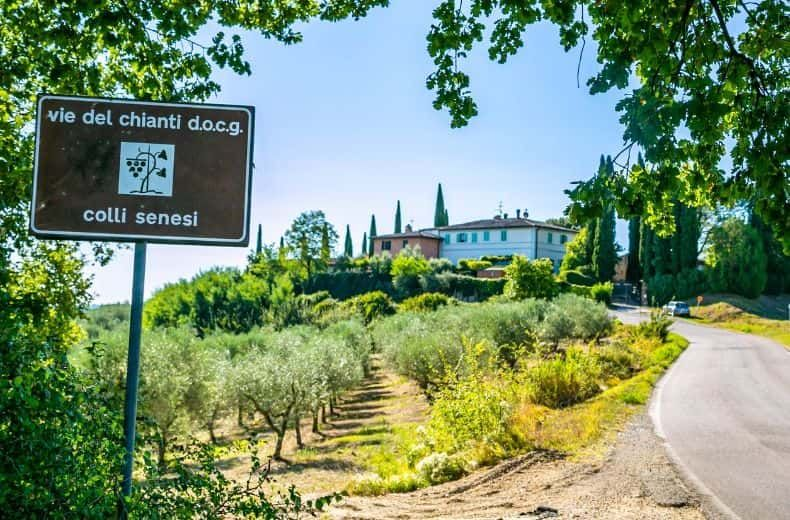

Running inference with Gemma 3n...


Structured JSON Response:
{
  "input_type": "image",
  "description": "A road sign in Italy indicating 'Vie del Chianti d.o.c.g. Colli Senesi'. It is situated on a country road surrounded by olive groves and vineyards, with a hilly landscape and blue sky in the background.",
  "extracted_text": [
    {
      "original": "vie del chianti d.o.c.g. colli senesi",
      "translation": "Chianti road certified designation of origin, Colli Senesi"
    }
  ],
  "object_type": "road sign",
  "suggested_reply": "This sign indicates you are entering the Chianti region of Tuscany. It's a beautiful area for wine tasting!",
  "cultural_tips": [
    "Tuscany is known for its relaxed pace of life. Enjoy the 'dolce vita' (sweet life)!",
    "Don't be afraid to stop and admire the scenery."
  ]
}


In [6]:
# Uploaded image (e.g. Japanese road sign)
# link = "https://inhabitat.com/wp-content/blogs.dir/1/files/2017/04/Swindon-Magic-Roundabout2.jpg"
# link = "https://tabimaniajapan.com/wp-content/uploads/2023/12/STOP_SIGN_JAPAN.jpg"
link = "https://d1gymyavdvyjgt.cloudfront.net/drive/images/uploads/headers/ws_cropper/1_0x0_790x520_0x520_1_0x0_790x520_0x520_italian-road-signs-header.jpg"
run_travel_translator(link, region_hint="Italy")

In [7]:
# Text input (phrase translation)
run_travel_translator("How do I say thank you in Korean?", region_hint="South Korea")

Starting Travel Translator...

Detected input type: text
Running inference with Gemma 3n...


Structured JSON Response:
{
  "input_type": "text",
  "description": "A user asking for the Korean translation of 'thank you'.",
  "extracted_text": [
    {
      "original": "How do I say thank you in Korean?",
      "translation": "How do I say thank you in Korean?"
    }
  ],
  "object_type": "phrase",
  "suggested_reply": "You can say '감사합니다' (gamsahamnida) which is a formal way of saying thank you. For a less formal way, you can say '고맙습니다' (gomapseumnida).",
  "cultural_tips": [
    "Bowing slightly is a common gesture of gratitude in Korean culture.",
    "It is considered polite to use honorifics when speaking to elders or people of higher status."
  ]
}


In [8]:
# Simulated audio (Spanish)
# run_travel_translator("dummy_audio.wav", region_hint="Spain")

Starting Travel Translator...

Detected input type: image
Image loaded successfully. Preview below:



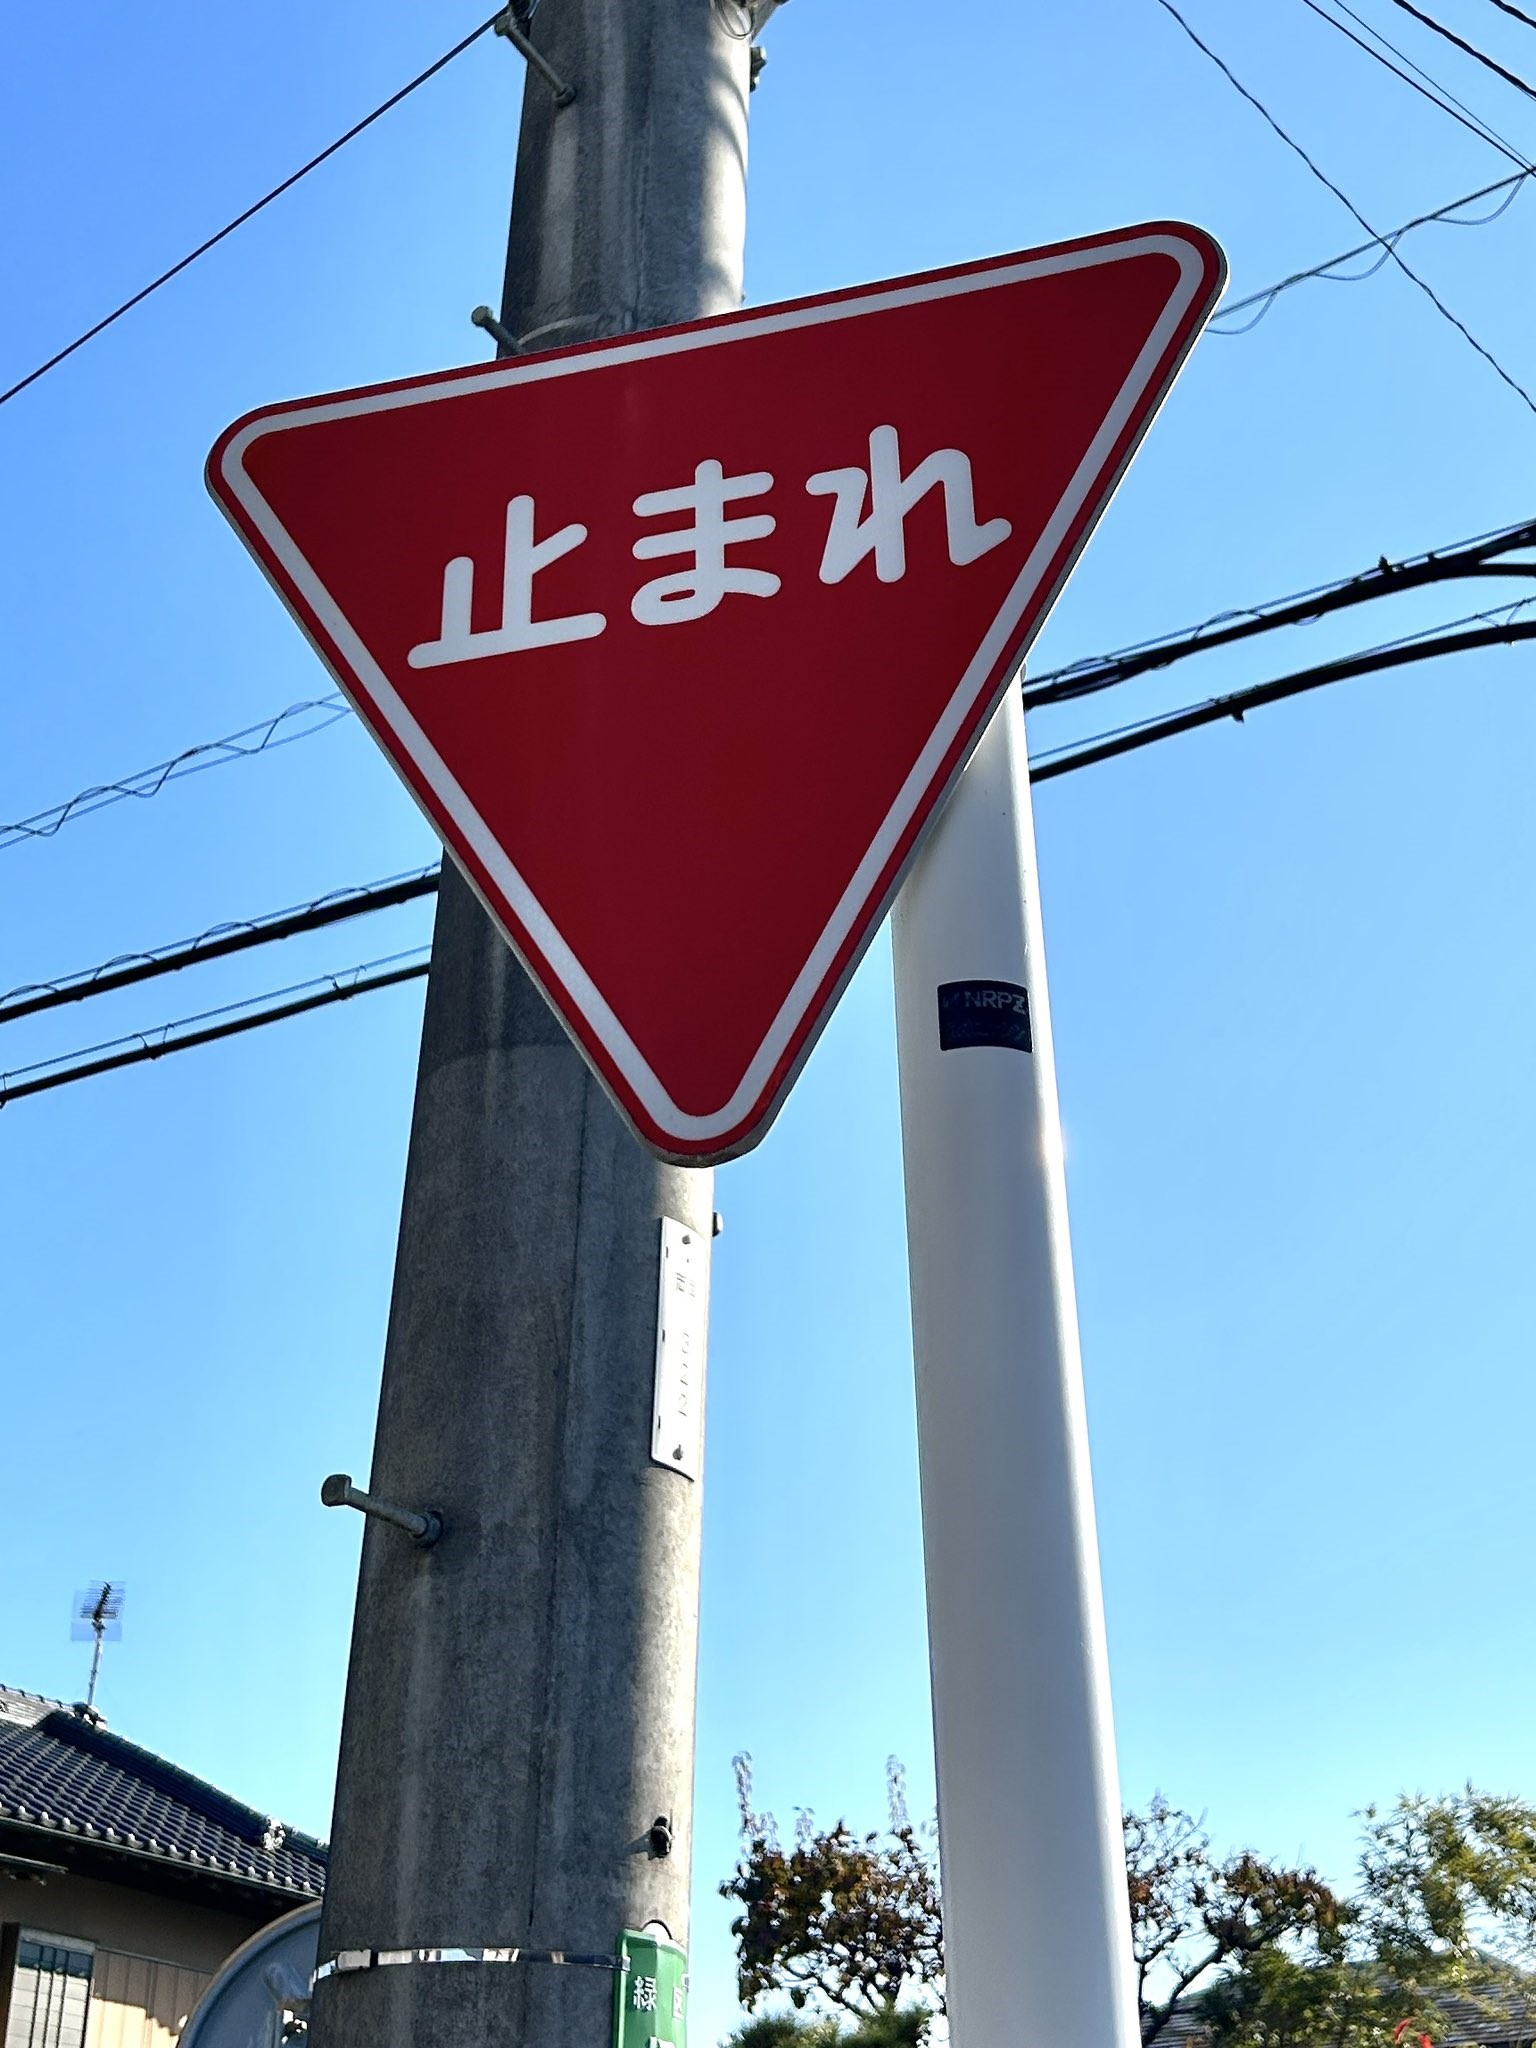

Running inference with Gemma 3n...


Structured JSON Response:
{
  "input_type": "image",
  "description": "A red triangular road sign with white Japanese text on a pole against a clear blue sky.",
  "extracted_text": [
    {
      "original": "止まれ",
      "translation": "Stop"
    }
  ],
  "object_type": "road sign",
  "suggested_reply": "The sign indicates that you must stop.",
  "cultural_tips": [
    "In Japan, traffic signs are very important and should always be obeyed.  It's also common to use a slight bow when acknowledging a sign."
  ]
}


In [9]:
link = "https://tabimaniajapan.com/wp-content/uploads/2023/12/STOP_SIGN_JAPAN.jpg"
run_travel_translator(link, region_hint="Japan")